In [1]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib


In [2]:
stats_df = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/4_attributeclusters/station_variable_statistics.csv")
GEV_clusters = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/4_attributeclusters/gev_fit_scores_kmeans_gev_k3.csv")

# --- Merge labels into stats ---
# Ensure station is comparable dtype
stats_df["station"] = stats_df["station"].astype(int)
GEV_clusters["station"] = GEV_clusters["station"].astype(int)

label_df = GEV_clusters[["station", "cluster", "lat", "lon"]].dropna().copy()
label_df["cluster"] = label_df["cluster"].astype(int)

# Inner join: only stations that exist in both
model_df = stats_df.merge(label_df, on="station", how="inner")

print("Stations for modeling:", len(model_df))
print(model_df["cluster"].value_counts(dropna=False))

drop_cols = {"station", "cluster"}

# Substrings that indicate leakage / forbidden variables
forbidden_substrings = ( "sea_level", "residual", "tide", "lat", "lon", "count", "missing_frac")

# Drop any column containing forbidden substrings (case-insensitive)
forbidden_cols = {
    c for c in model_df.columns
    if any(sub in c.lower() for sub in forbidden_substrings)
}
cols_to_drop = drop_cols | forbidden_cols

# Build feature matrix
X = model_df.drop(columns=[c for c in cols_to_drop if c in model_df.columns])

y = model_df['cluster']

Stations for modeling: 279
cluster
1    136
0    122
2     21
Name: count, dtype: int64


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=0,
    stratify=y
)

print("Train size:", X_train.shape, " Test size:", X_test.shape)
print("Train class counts:\n", y_train.value_counts())
print("Test class counts:\n", y_test.value_counts())


Train size: (209, 165)  Test size: (70, 165)
Train class counts:
 cluster
1    102
0     91
2     16
Name: count, dtype: int64
Test class counts:
 cluster
1    34
0    31
2     5
Name: count, dtype: int64


In [5]:
drop_cols = {"station", "cluster"}
forbidden_substrings = ("sea_level", "residual", "tide", "count", "missing")
forbidden_cols = {c for c in model_df.columns if any(s in c.lower() for s in forbidden_substrings)}

X = model_df.drop(columns=[c for c in (drop_cols | forbidden_cols) if c in model_df.columns])
X = X.apply(pd.to_numeric, errors="coerce")
X = X.dropna(axis=1, how="all")


# Cluster Bath stats

In [6]:
ds_sealevel = GEV_clusters

In [7]:
# Open the GEBCO NetCDF file
file_path = "/Users/lb962/Documents/Phd/AExtremesEOF/data/GEBCO/gebco_2024_n70.0_s47.0_w-20.0_e15.0.nc"
GEBCO_ds = xr.open_dataset(file_path)

# extract station ids and their lat/lon
stations = ds_sealevel['station'].values
lats = ds_sealevel['lat'].values
lons = ds_sealevel['lon'].values

# build mapping from (lat, lon) to station index
latlon_to_station = {
    (float(lat), float(lon)): int(stn)
    for stn, lat, lon in zip(stations, lats, lons)
}

# if you want unique lat/lon pairs:
unique_latlon = list(latlon_to_station.keys())

# Function to extract square around a lat/lon
def extract_square(ds, lat, lon, size_deg):
    half = size_deg / 2
    return ds.sel(
        lat=slice(lat + half, lat - half),  # GEBCO lat usually descending
        lon=slice(lon - half, lon + half),
        method="nearest"
    )

results = {
    "0.1x0.1": [],
    "0.25x0.25": [],
    "1x1": [],
    "3x3": [],
    "10x10":[]
}
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

def mask_land_gt1m(ds_tile):
    """Mask elevations shallower than -0.5 m (land/coast) as NaN."""
    return ds_tile.assign(elevation=ds_tile["elevation"].where(ds_tile["elevation"] <= -0.5))

def plot_tile(ds_tile, title="GEBCO bathymetry (masked, with station)"):
    """Plot a masked GEBCO tile with Cartopy and a red station dot at the center."""
    masked = mask_land_gt1m(ds_tile)

    # Compute the center coordinate (station location)
    center_lat = float(masked.lat.mean())
    center_lon = float(masked.lon.mean())
    
    fig = plt.figure(figsize=(6, 4))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Bathymetry raster
    pcm = ax.pcolormesh(
        masked["lon"], masked["lat"], masked["elevation"],
        transform=ccrs.PlateCarree()
    )

    # Coastlines and extent
    ax.coastlines(resolution="10m")
    ax.set_title(title)
    ax.set_extent([
        float(masked.lon.min()), float(masked.lon.max()),
        float(masked.lat.min()), float(masked.lat.max())
    ], crs=ccrs.PlateCarree())

    # Station red dot
    ax.plot(center_lon, center_lat, 'ro', markersize=6, transform=ccrs.PlateCarree())

    # Colorbar
    plt.colorbar(pcm, ax=ax, label="Elevation (m)")
    plt.show()

def extract_square(ds, lat, lon, size_deg):
    """Fast spatial slice using coordinate indices."""
    half = size_deg / 2
    return ds.sel(
        lat=slice(lat - half, lat + half),
        lon=slice(lon - half, lon + half)
    )

# --- Prep: ensure coordinates are monotonic so .sel(slice) is efficient ---
GEBCO_ds = GEBCO_ds.sortby(["lat", "lon"])

# Available resolutions (keep all for each point)
#resolutions = [0.1, 0.25, 1.0, 3.0, 10.0]
resolutions = [0.1, 0.25, 1]

# Initialize results dict
results = {f"{r}x{r}": [] for r in resolutions}
#results = {r: [] for r in resolutions}

# Build tiles for every (lat, lon) at every resolution
for lat, lon in unique_latlon:
    for size in resolutions:
        key = f"{size}x{size}"
        results[key].append(extract_square(GEBCO_ds, lat, lon, size))

In [8]:
import numpy as np
import xarray as xr

import numpy as np
import xarray as xr

def to_128x128(ds_tile: xr.Dataset, H: int = 128, W: int = 128) -> xr.Dataset:
    """
    Resize a tile to (H,W) using xarray interp.
    Robust to empty / degenerate tiles and to descending coords.
    """
    # Basic dimension checks
    if ("lat" not in ds_tile.dims) or ("lon" not in ds_tile.dims):
        raise ValueError(f"Tile missing lat/lon dims: dims={ds_tile.dims}")

    nlat = ds_tile.sizes.get("lat", 0)
    nlon = ds_tile.sizes.get("lon", 0)

    # Empty tile: return a blank (NaN) tile with target coords
    if nlat == 0 or nlon == 0:
        # Try to preserve variable names; create NaN arrays for vars on (lat, lon)
        lat = np.linspace(0.0, 0.0, H, dtype=np.float32)
        lon = np.linspace(0.0, 0.0, W, dtype=np.float32)
        out = xr.Dataset(coords={"lat": lat, "lon": lon})
        for v in ds_tile.data_vars:
            if set(ds_tile[v].dims) >= {"lat", "lon"}:
                out[v] = xr.DataArray(np.full((H, W), np.nan, dtype=np.float32), dims=("lat", "lon"))
        return out

    # Degenerate tile: interp needs at least 2 points along each axis for linear
    # (if you can accept nearest, you can switch methods conditionally)
    method = "linear"
    if nlat < 2 or nlon < 2:
        method = "nearest"

    # Ensure monotonic ascending coords for interp
    ds = ds_tile.sortby(["lat", "lon"])

    lat0 = float(ds["lat"].values[0])
    lat1 = float(ds["lat"].values[-1])
    lon0 = float(ds["lon"].values[0])
    lon1 = float(ds["lon"].values[-1])

    new_lat = np.linspace(lat0, lat1, H, dtype=np.float32)
    new_lon = np.linspace(lon0, lon1, W, dtype=np.float32)

    return ds.interp(lat=new_lat, lon=new_lon, method=method)

# --- apply to every tile in your dict ---
results_128 = {k: [to_128x128(ds) for ds in tiles] for k, tiles in results.items()}

# sanity check (first available tile per bucket should be 128x128)
for k, tiles in results_128.items():
    if tiles:
        shp = tiles[0]["elevation"].shape
        assert shp == (128, 128), f"{k} -> {shp}, expected (128, 128)"

del GEBCO_ds

rows = []
for i, (lat, lon) in enumerate(unique_latlon):
    row = {"latitude": lat, "longitude": lon}
    for size in resolutions:
        key = f"{size}x{size}"
        xr_tile = results_128[key][i]
        elev = xr_tile["elevation"].where(xr_tile["elevation"] <= -0.5)
        row[f"tile_{size}"] = elev.values  # 2D array
        # save plotting extent = [lon_min, lon_max, lat_min, lat_max]
        row[f"extent_{size}"] = [
            float(xr_tile["lon"].min()), float(xr_tile["lon"].max()),
            float(xr_tile["lat"].min()), float(xr_tile["lat"].max())
        ]
    rows.append(row)

df = pd.DataFrame(rows)

In [9]:
import numpy as np

def _station_pixel_indices(st_lat, st_lon, extent, ny, nx):
    lon_min, lon_max, lat_min, lat_max = extent
    dlon = (lon_max - lon_min) / (nx - 1)
    dlat = (lat_max - lat_min) / (ny - 1)

    if lat_max >= lat_min:  # ascending latitude
        iy = int(round((st_lat - lat_min) / dlat))
    else:                   # descending latitude
        dlat = (lat_min - lat_max) / (ny - 1)
        iy = int(round((lat_min - st_lat) / dlat))

    ix = int(round((st_lon - lon_min) / dlon))
    iy = np.clip(iy, 0, ny - 1)
    ix = np.clip(ix, 0, nx - 1)
    return iy, ix, dlat, dlon

def _meters_per_degree(lat_deg):
    lat_rad = np.deg2rad(lat_deg)
    return 111_132.0, 111_320.0 * np.cos(lat_rad)

def tile_stats_near_station(tile, extent, st_lat, st_lon, radius_cells=3):
    """
    Stats in a (2r+1)^2 window near station:
      - slope (deg)   [mean of gradient magnitude in deg]
      - roughness std (m)
      - relief p2p (m)
      - mean bathymetry (m) over ocean-only cells (<= -0.5 m)
    """
    if tile is None or np.all(np.isnan(tile)):
        return np.nan, np.nan, np.nan, np.nan

    ny, nx = tile.shape
    iy, ix, dlat_deg, dlon_deg = _station_pixel_indices(st_lat, st_lon, extent, ny, nx)

    y0 = max(0, iy - radius_cells); y1 = min(ny, iy + radius_cells + 1)
    x0 = max(0, ix - radius_cells); x1 = min(nx, ix + radius_cells + 1)

    sub = tile[y0:y1, x0:x1]
    if sub.size == 0 or np.all(np.isnan(sub)):
        return np.nan, np.nan, np.nan, np.nan

    # Ocean-only mask for mean bathy
    sub_ocean = np.where(sub <= -0.5, sub, np.nan)
    mean_bathy = float(np.nanmean(sub_ocean))

    # Pixel spacings (meters) at station latitude
    m_per_deg_lat, m_per_deg_lon = _meters_per_degree(st_lat)
    dy_m = dlat_deg * m_per_deg_lat
    dx_m = dlon_deg * m_per_deg_lon

    # Gradients (fill small NaN gaps just for gradient)
    sub_filled = np.where(np.isnan(sub), np.nanmean(sub), sub) if np.isnan(sub).any() else sub
    gy, gx = np.gradient(sub_filled, dy_m, dx_m)
    slope_mag = np.sqrt(gx**2 + gy**2)           # rise/run
    slope_deg = np.degrees(np.arctan(slope_mag)) # to degrees
    slope_deg = np.where(np.isnan(sub), np.nan, slope_deg)

    slope_local = float(np.nanmean(slope_deg))
    roughness_std = float(np.nanstd(sub))
    relief_p2p = float(np.nanmax(sub) - np.nanmin(sub))

    return slope_local, roughness_std, relief_p2p, mean_bathy

# ---- Apply to all resolutions and add columns ----
radius_cells = 3  # e.g., 7x7 window; tweak as needed

for size in resolutions:  # [0.1, 0.25, 1.0, 3.0, 10.0]
    key = f"{size}"
    tile_col   = f"tile_{key}"
    extent_col = f"extent_{key}"

    df[f"slope_deg_{key}"]      = np.nan
    df[f"roughness_std_{key}"]  = np.nan
    df[f"relief_p2p_{key}"]     = np.nan
    df[f"mean_bathy_{key}"]     = np.nan

    for idx in range(len(df)):
        tile = df.at[idx, tile_col]
        extent = df.at[idx, extent_col]
        st_lat = df.at[idx, "latitude"]
        st_lon = df.at[idx, "longitude"]

        s, rstd, rpp, mb = tile_stats_near_station(tile, extent, st_lat, st_lon, radius_cells)
        df.at[idx, f"slope_deg_{key}"]     = s
        df.at[idx, f"roughness_std_{key}"] = rstd
        df.at[idx, f"relief_p2p_{key}"]    = rpp
        df.at[idx, f"mean_bathy_{key}"]    = mb

# Quick peek
print(df.filter(regex=r'^(latitude|longitude|slope_deg_|roughness_std_|relief_p2p_|mean_bathy_)').head())

    latitude  longitude  slope_deg_0.1  roughness_std_0.1  relief_p2p_0.1  \
0  48.383000  -4.495000       0.314652           0.618534        2.797581   
1  45.568480  -1.061555            NaN                NaN             NaN   
2  50.102000  -5.542000       0.469762           0.892700        4.550620   
3  50.103000  -5.542750       0.716422           1.212880        5.287394   
4  50.099998  -5.533330       0.471409           0.975480        4.209303   

   mean_bathy_0.1  slope_deg_0.25  roughness_std_0.25  relief_p2p_0.25  \
0       -1.354011        0.591017            2.602795         7.936331   
1             NaN             NaN                 NaN              NaN   
2       -4.932380        0.464575            2.025659         7.411496   
3       -4.070334        0.465226            2.143751         7.852673   
4       -8.839199        0.512022            2.552270        10.623257   

   mean_bathy_0.25  slope_deg_1  roughness_std_1  relief_p2p_1  mean_bathy_1  
0        -4.2

In [15]:
drop_cols = {"station", "cluster"}
forbidden_substrings = ("sea_level", "bath_cluster", "residual", "tide", "count", "missing", "latitude", "longitude")
forbidden_cols = {c for c in model_df.columns if any(s in c.lower() for s in forbidden_substrings)}

X_bath = df.drop(columns=[c for c in (drop_cols | forbidden_cols) if c in df.columns])
X_bath = X_bath.apply(pd.to_numeric, errors="coerce")
X_bath = X_bath.dropna(axis=1, how="all")
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

met_pre = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

Xs = met_pre.fit_transform(X_bath)
from sklearn.decomposition import PCA

pca = PCA(n_components=0.9, whiten=True)  # retain 90% variance
Xs = pca.fit_transform(Xs)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 11)
sil = {}

for k in k_range:
    km_met = KMeans(n_clusters=k, random_state=0, n_init="auto")
    labels_met = km_met.fit_predict(Xs)
    sil[k] = silhouette_score(Xs, labels_met)

best_k_met = max(sil, key=sil.get)
km_met = KMeans(n_clusters=best_k_met, random_state=0, n_init="auto")
met_cluster = km_met.fit_predict(Xs)

df = df.copy()
df["bath_cluster"] = met_cluster

/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_47911/2610086348.py:9: RuntimeWarning: Mean of empty slice
  feature_cols[col] = df[col].apply(lambda x: np.nanmean(x))


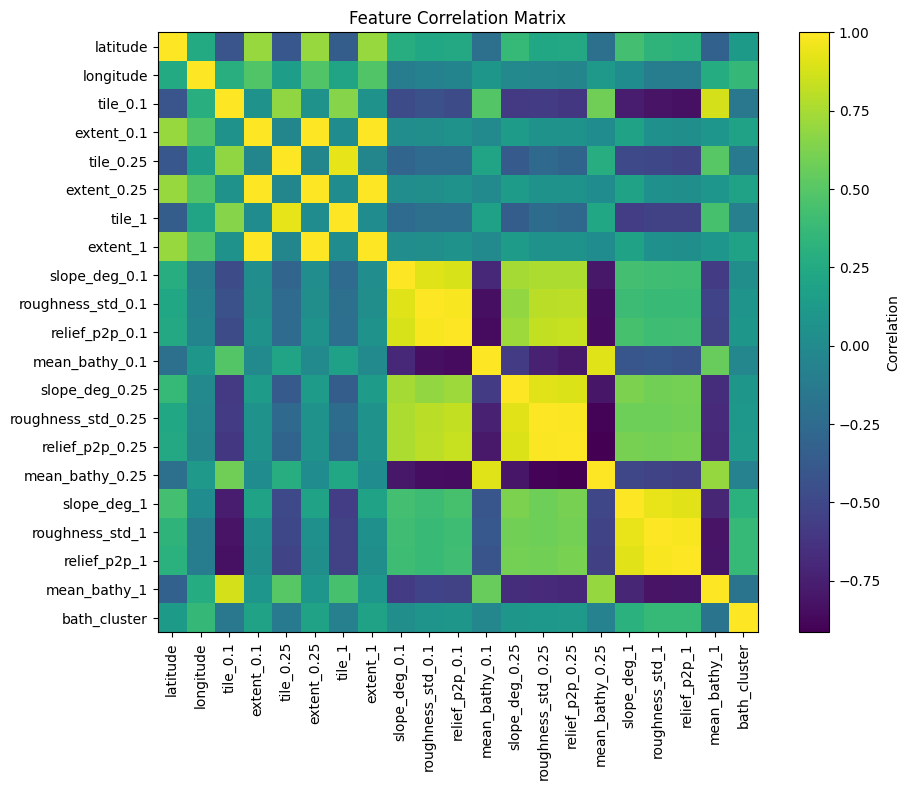

In [11]:
import numpy as np
import pandas as pd

feature_cols = {}

for col in df.columns:
    if df[col].dtype == object:
        # assume tiles (2D arrays)
        feature_cols[col] = df[col].apply(lambda x: np.nanmean(x))
    else:
        # numeric scalars like latitude / longitude
        feature_cols[col] = df[col]

feat_df = pd.DataFrame(feature_cols)
corr = feat_df.corr()
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.imshow(corr.values)
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
plt.colorbar(label="Correlation")
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()



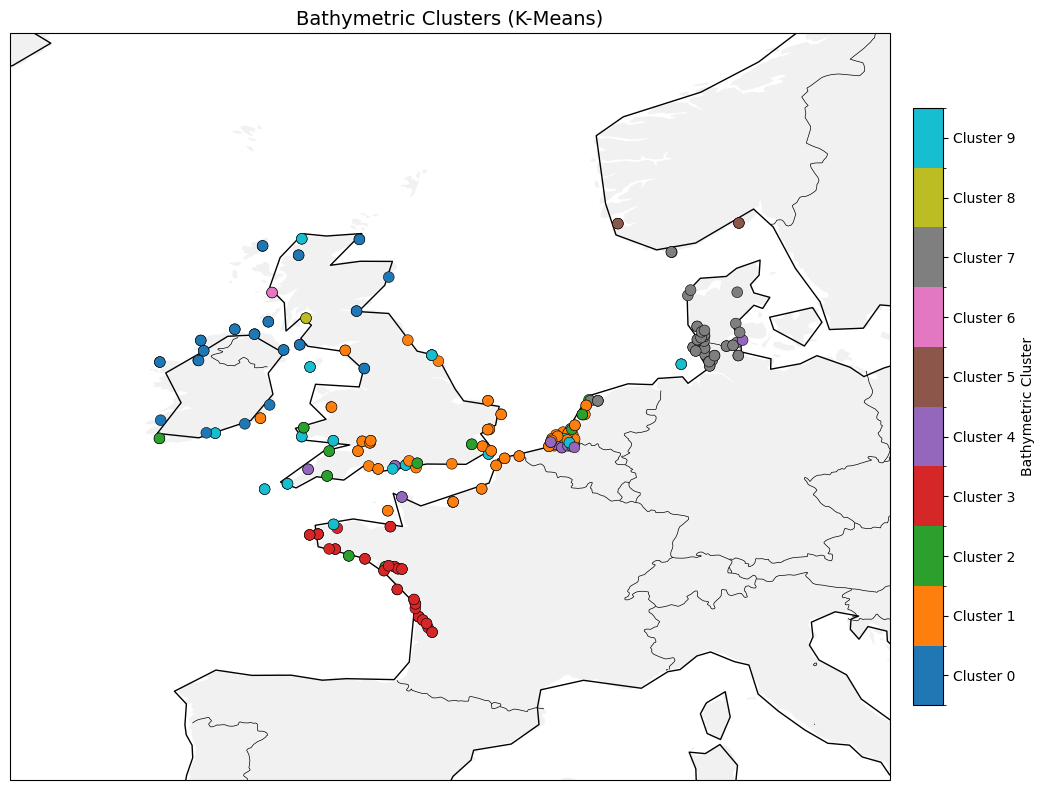

In [12]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm

# -----------------------------
# Prepare discrete colormap
# -----------------------------
clusters = np.sort(df["bath_cluster"].unique())
n_clusters = len(clusters)

# Use a base categorical colormap and discretize it
base_cmap = plt.get_cmap("tab10")  # good for discrete categories
colors = base_cmap(range(n_clusters))
cmap = ListedColormap(colors)

bounds = np.arange(-0.5, n_clusters + 0.5, 1)
norm = BoundaryNorm(bounds, cmap.N)

# -----------------------------
# Create Cartopy map
# -----------------------------
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_global()  # or restrict extent if desired
ax.coastlines(resolution="110m", linewidth=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.3)
ax.add_feature(cfeature.OCEAN, facecolor="white", alpha=0.3)

# -----------------------------
# Scatter plot of stations
# -----------------------------
sc = ax.scatter(
    df["longitude"],
    df["latitude"],
    c=df["bath_cluster"],
    cmap=cmap,
    norm=norm,
    s=60,
    edgecolor="black",
    linewidth=0.4,
    transform=ccrs.PlateCarree(),
    zorder=3
)

cbar = plt.colorbar(
    sc,
    ax=ax,
    orientation="vertical",
    pad=0.02,
    shrink=0.8,
    ticks=clusters
)
cbar.set_label("Bathymetric Cluster")
cbar.set_ticks(clusters)
cbar.set_ticklabels([f"Cluster {i}" for i in clusters])

ax.set_title("Bathymetric Clusters (K-Means)", fontsize=14)
ax.set_extent([-15,15,40,65])

plt.tight_layout()
plt.show()


In [20]:
import numpy as np
import pandas as pd

# Recover fitted objects
imputer = met_pre.named_steps["imputer"]
scaler  = met_pre.named_steps["scaler"]

# KMeans centers are in PCA space
centers_pca = km_met.cluster_centers_          # shape: (k, n_components)

# --- Invert PCA, taking whitening into account ---
# If whiten=True, sklearn's PCA stores components_ in the original (unwhitened) basis,
# but the transformed space is whitened by dividing by sqrt(explained_variance_).
# So to invert from whitened PCA coords, multiply back by sqrt(explained_variance_) first.
if getattr(pca, "whiten", False):
    centers_unwhitened = centers_pca * np.sqrt(pca.explained_variance_)
else:
    centers_unwhitened = centers_pca

# PCA space -> standardized feature space
centers_scaled = pca.inverse_transform(centers_unwhitened)  # (k, n_features)

# standardized -> physical (imputed) feature space
centers_phys = scaler.inverse_transform(centers_scaled)

centroids_bath_phys = pd.DataFrame(centers_phys, columns=X_bath.columns)
centroids_bath_phys


,latitude,longitude,slope_deg_0.1,roughness_std_0.1,relief_p2p_0.1,mean_bathy_0.1,slope_deg_0.25,roughness_std_0.25,relief_p2p_0.25,mean_bathy_0.25,slope_deg_1,roughness_std_1,relief_p2p_1,mean_bathy_1,bath_cluster
0,55.476165,-5.804253,1.654940,2.304730,7.937797,-5.585496,1.129536,3.732707,12.840234,-8.281695,0.575566,7.891396,27.513567,-17.194943,0.103283
1,50.482424,3.327399,-0.106000,-0.179035,-0.812171,0.068018,-0.142702,-0.592167,-2.476723,0.856217,-0.074299,-0.740335,-3.600162,1.305967,1.726379
2,48.291973,-3.227420,-0.076245,-0.218660,-1.000840,-0.086173,-0.034779,-0.116596,-0.846844,-0.255745,-0.026086,0.764949,1.963652,-2.461216,2.123207
3,68.176383,6.285865,6.749818,11.139824,40.533305,-27.216851,5.357502,19.890272,70.649749,-40.082974,3.943058,48.819893,175.223137,-71.092903,10.707945
4,50.758331,-4.013370,4.507585,8.148376,28.033238,-18.903693,2.305512,10.126490,35.394517,-23.511771,0.758410,10.229776,37.899569,-22.502628,7.054054
5,51.848147,4.208534,2.922282,5.191837,18.300411,-12.198254,2.209065,8.852727,30.271514,-17.930692,0.838924,10.675623,39.043854,-18.527384,7.936993
6,53.928333,0.811184,2.815623,4.447802,16.203121,-10.683398,3.073731,11.179019,37.891214,-20.458825,1.338803,17.437011,63.256908,-29.482731,8.380355
7,55.848092,8.803190,0.595321,0.874096,3.052900,-2.007708,0.386568,1.007175,3.150067,-1.974348,0.205495,1.732808,5.141908,-2.536125,0.819136
8,51.448670,-1.539324,0.263438,0.240858,1.124351,-1.791984,0.499031,1.634647,5.793271,-3.351402,0.832185,11.445041,39.858838,-14.763552,3.451784
9,61.961490,-7.435770,11.629709,20.345080,71.027359,-46.709744,6.755329,27.708629,97.693874,-61.228878,2.931574,36.887693,135.681212,-70.700920,12.667363


In [22]:
ct = pd.crosstab(model_df["cluster"], df["bath_cluster"], normalize="index")
print(ct)


bath_cluster         0         1         2         3         4         5  \
cluster                                                                    
0             0.057377  0.401639  0.163934  0.000000  0.032787  0.090164   
1             0.205882  0.073529  0.367647  0.029412  0.073529  0.022059   
2             0.000000  0.000000  0.142857  0.000000  0.000000  0.142857   

bath_cluster         6         7         8         9  
cluster                                               
0             0.040984  0.131148  0.057377  0.024590  
1             0.007353  0.088235  0.125000  0.007353  
2             0.000000  0.714286  0.000000  0.000000  


In [24]:
from scipy.stats import chi2_contingency

ct_counts = pd.crosstab(model_df["cluster"], df["bath_cluster"])
chi2, p, dof, expected = chi2_contingency(ct_counts)

print("chi2:", chi2, "p-value:", p)


chi2: 135.89509078116262 p-value: 3.945451471853249e-20


In [26]:
from sklearn.metrics import mutual_info_score

mi = mutual_info_score(model_df["cluster"], df["bath_cluster"])
print("Mutual information:", mi)


Mutual information: 0.23033474952371966


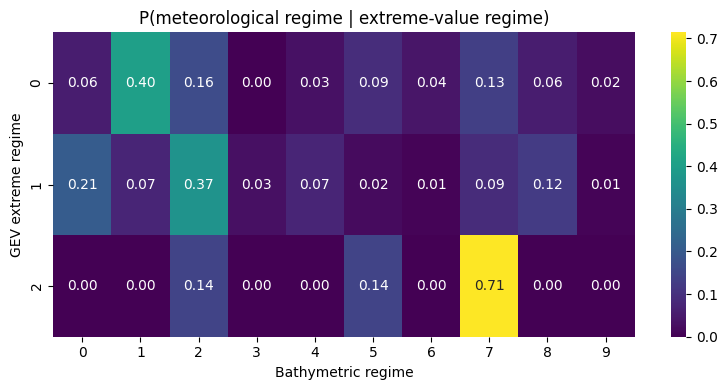

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

ct = pd.crosstab(model_df["cluster"], df["bath_cluster"], normalize="index")

plt.figure(figsize=(8,4))
sns.heatmap(ct, annot=True, fmt=".2f", cmap="viridis")

plt.xlabel("Bathymetric regime")
plt.ylabel("GEV extreme regime")
plt.title("P(meteorological regime | extreme-value regime)")

plt.tight_layout()
plt.show()


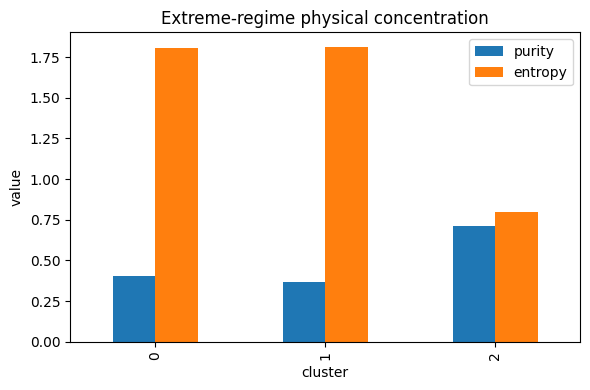

In [31]:
ct = pd.crosstab(model_df["cluster"], df["bath_cluster"], normalize="index")

dominant = ct.idxmax(axis=1)
purity = ct.max(axis=1)
entropy = -(ct * np.log(ct + 1e-12)).sum(axis=1)

summary = pd.DataFrame({
    "dominant_met_regime": dominant,
    "purity": purity,
    "entropy": entropy
})

summary[["purity", "entropy"]].plot(kind="bar", figsize=(6,4))
plt.title("Extreme-regime physical concentration")
plt.ylabel("value")
plt.tight_layout()
plt.show()


Interpretation:

purity → how concentrated the attribution is

entropy → how many meteorological pathways exist

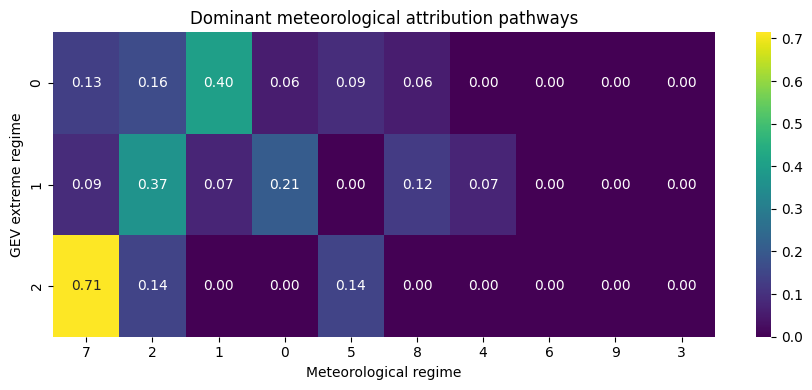

In [32]:
# order columns by overall contribution
order = ct.sum(axis=0).sort_values(ascending=False).index
ct_ord = ct[order]

# zero-out very small probabilities
ct_masked = ct_ord.where(ct_ord > 0.05, 0)

plt.figure(figsize=(9,4))
sns.heatmap(ct_masked, annot=True, fmt=".2f", cmap="viridis")
plt.xlabel("Meteorological regime")
plt.ylabel("GEV extreme regime")
plt.title("Dominant meteorological attribution pathways")
plt.tight_layout()
plt.show()


In [45]:
model_df

,station,u10__mean,u10__std,u10__min,u10__max,u10__median,u10__q05,u10__q95,u10__count,u10__missing_frac,...,residual_is_deviant__annmax_std,residual_is_deviant__annmax_min,residual_is_deviant__annmax_max,residual_is_deviant__annmean_mean,residual_is_deviant__annmean_std,residual_is_deviant__annmean_min,residual_is_deviant__annmean_max,cluster,lat,lon
0,1,1.435309,5.204763,-16.211533,26.093597,1.500458,-6.847014,10.088026,750192,0.0,...,0.000000,0,0,0.000000,0.000000,0.0,0.000000,1,48.383000,-4.495000
1,10,1.033226,4.597254,-15.020645,23.730011,0.919975,-6.038169,8.888404,750192,0.0,...,0.000000,0,0,0.000000,0.000000,0.0,0.000000,1,45.568480,-1.061555
2,102,1.807468,5.515200,-17.559769,22.360794,2.133461,-7.619794,10.497694,750192,0.0,...,0.000000,0,0,0.000000,0.000000,0.0,0.000000,1,50.102000,-5.542000
3,103,1.807468,5.515200,-17.559769,22.360794,2.133461,-7.619794,10.497694,750192,0.0,...,0.333986,0,1,0.008964,0.039935,0.0,0.241667,0,50.103000,-5.542750
4,104,1.807468,5.515200,-17.559769,22.360794,2.133461,-7.619794,10.497694,750192,0.0,...,0.254755,0,1,0.002223,0.014116,0.0,0.104736,0,50.099998,-5.533330
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274,93,1.321126,4.322766,-13.039688,18.429459,1.281563,-5.325874,8.531832,750192,0.0,...,0.000000,0,0,0.000000,0.000000,0.0,0.000000,0,49.930000,1.085000
275,94,1.017265,4.200128,-13.300308,19.863937,0.958878,-5.435812,8.052494,750192,0.0,...,0.000000,0,0,0.000000,0.000000,0.0,0.000000,1,49.481602,0.105600
276,95,1.408155,5.313808,-16.098816,22.026306,1.785545,-7.461143,9.700240,750192,0.0,...,0.000000,0,0,0.000000,0.000000,0.0,0.000000,1,49.651299,-1.635500
277,97,1.463534,5.589287,-16.075241,26.132431,1.500534,-7.341267,10.628401,750192,0.0,...,0.150715,0,1,0.000023,0.000175,0.0,0.001598,1,49.183300,-2.116700


In [46]:
df["lat"] = df["latitude"]
df["lon"] = df["longitude"]

In [47]:
merged_df = pd.merge(df, model_df, on=["lat", "lon"])

In [58]:
if "bath_cluster" in getattr(df.index, "names", []):
    df = df.reset_index()


In [61]:
feat_cols = list(X_bath.columns)

summary = (
    merged_df[["cluster", "bath_cluster"] + feat_cols]
      .groupby(["cluster", "bath_cluster"])
      .median(numeric_only=True)
)

# Composite score: mean absolute z-score across bathymetry features
from sklearn.preprocessing import StandardScaler
Z = StandardScaler().fit_transform(summary.values)
summary_z = pd.DataFrame(Z, index=summary.index, columns=summary.columns)

score = summary_z.abs().mean(axis=1).unstack("bath_cluster")  # rows=GEV, cols=bathy


ValueError: Grouper for 'bath_cluster' not 1-dimensional

In [59]:
import pandas as pd

group_cols = ["cluster", "bath_cluster"]
feat_cols  = X_bath.columns

summary = (
    merged_df[group_cols + list(feat_cols)]
      .groupby(group_cols)
      .median(numeric_only=True)
)


ValueError: Grouper for 'bath_cluster' not 1-dimensional

In [50]:
import numpy as np
import pandas as pd

print("Count of 'bath_cluster' columns:", (df.columns == "bath_cluster").sum())
print("Columns that match:", [c for c in df.columns if c == "bath_cluster"])

obj = df.loc[:, "bath_cluster"]
print("Type:", type(obj))
print("Shape:", getattr(obj, "shape", None))


Count of 'bath_cluster' columns: 1
Columns that match: ['bath_cluster']
Type: <class 'pandas.core.series.Series'>
Shape: (279,)


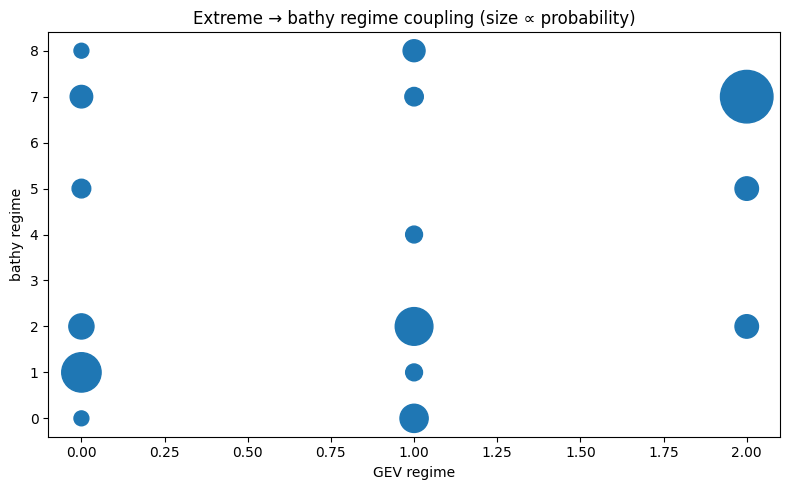

In [38]:
import matplotlib.pyplot as plt

flows = ct.stack().reset_index()
flows.columns = ["gev", "met", "p"]
flows = flows[flows["p"] > 0.05]  # keep only meaningful links

plt.figure(figsize=(8,5))
plt.scatter(flows["gev"], flows["met"], s=flows["p"]*2000)
plt.xlabel("GEV regime")
plt.ylabel("bathy regime")
plt.title("Extreme → bathy regime coupling (size ∝ probability)")
plt.tight_layout()
plt.show()


In [40]:
ct2 = pd.crosstab(df["bath_cluster"], model_df["cluster"], normalize="index")
print(ct2)


cluster              0         1         2
bath_cluster                              
0             0.200000  0.800000  0.000000
1             0.830508  0.169492  0.000000
2             0.273973  0.684932  0.041096
3             0.000000  1.000000  0.000000
4             0.285714  0.714286  0.000000
5             0.647059  0.176471  0.176471
6             0.833333  0.166667  0.000000
7             0.372093  0.279070  0.348837
8             0.291667  0.708333  0.000000
9             0.750000  0.250000  0.000000
